In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [7]:
data=load_breast_cancer()
X=data.data
y=data.target

In [10]:
pca = PCA(n_components=2)
X=pca.fit_transform(X)


In [12]:
x_train,x_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [15]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [34]:
model=SVC(kernel='linear',C=1)
model.fit(x_train,y_train)

SVC(C=1, kernel='linear')

In [35]:
y_pred=model .predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.9649122807017544


In [36]:
def plot_svm(model,X,y):
    plt.figure(figsize=(8,6))
    plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
    ax=plt.gca()
    xlim=ax.get_xlim()
    ylim=ax.get_ylim()
    xx=np.linspace(xlim[0],xlim[1],100)
    yy=np.linspace(xlim[0],xlim[1],100)
    YY,XX=np.meshgrid(yy,xx)
    xy=np.vstack([XX.ravel(),YY.ravel()]).T
    Z=model.decision_function(xy)
    Z=Z.reshape(XX.shape)
    ax.contour(XX,YY,Z,levels=[0],colors="black")
    ax.contour(XX,YY,Z,levels=[-1,1],colors="black",linestyles="dashed")
    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors="none",
        edgecolors="black"
    )
    plt.title("Linear SVM Decision Boundary")
    plt.show()


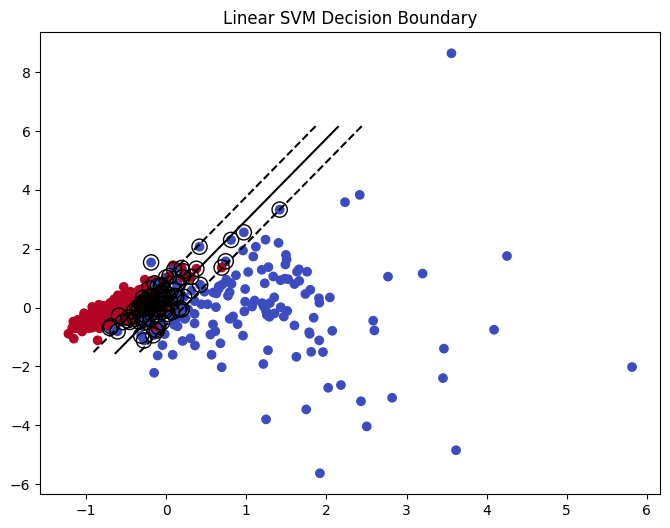

In [37]:
plot_svm(model,x_train,y_train)